In [67]:
# Import the pandas library for data manipulation
import pandas as pd

# Load the Excel file into a pandas DataFrame
df = pd.read_excel("ttwf_Student_Breakdown_11-06-2026.xlsx")

In [68]:
# Remove the first 4 rows which contain header information that is not part of the data
df = df.iloc[4:].reset_index(drop=True)

In [69]:
# Set the first row of the DataFrame as the column headers
df.columns = df.iloc[0]

In [70]:
# Remove the row that was just used for column headers, as it's no longer needed in the data
df = df.iloc[1:].reset_index(drop=True)

In [85]:
# To opt into future pandas behavior for fillna and suppress the FutureWarning
pd.set_option('future.no_silent_downcasting', True)
# Fill any 'N/A' values (which represent missing data) with the string 'N/A'
df = df.fillna('N/A')

In [ ]:
# Import necessary libraries for plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Display the first few rows of the DataFrame to check its structure and content
display(df.head())

In [73]:
# Set a professional seaborn style and palette for all plots
sns.set_theme(style='whitegrid', palette='viridis')

In [74]:
# Define a list of columns that are expected to contain numeric data
numeric_cols = [
    'Earned Stars',
    'Days Played',
    'Completed Lessons (All)',
    'Completed Lessons (Math)',
    'Completed Lessons (Eng)',
    'Play Time',
    'Core Time',
    'Library Time',
    'Play Time (Math)',
    'Play Time (Eng)',
    'Birth Year' # Birth Year should be numeric for age calculations later
]

# Iterate through the list of numeric columns and convert them to numeric type
# 'errors="coerce"' will turn any non-convertible values into NaN (Not a Number)
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

In [75]:
# Define additional relevant columns to be converted to numeric
additional_numeric_cols = [
    'Completed Lessons (All)',
    'Completed Lessons (Math)',
    'Completed Lessons (Eng)',
    'Play Time',
    'Core Time',
    'Library Time',
    'Play Time (Math)',
    'Play Time (Eng)'
]

# Iterate and convert these columns to numeric, coercing errors to NaN
for col in additional_numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

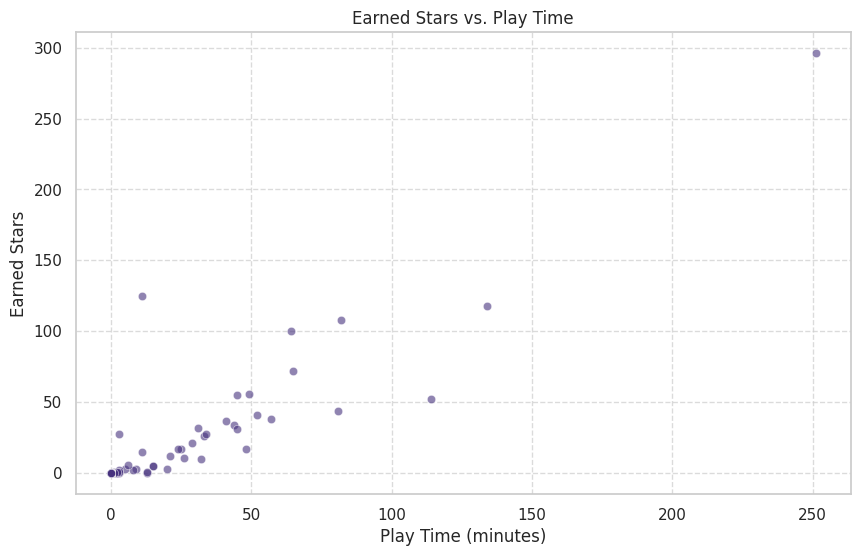

In [76]:
# Create a scatter plot to visualize the relationship between 'Earned Stars' and 'Play Time'
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df.sample(n=min(len(df), 5000), random_state=42), # Sample data for performance
                x='Play Time', y='Earned Stars',
                alpha=0.6)
plt.title('Earned Stars vs. Play Time')
plt.xlabel('Play Time (minutes)')
plt.ylabel('Earned Stars')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

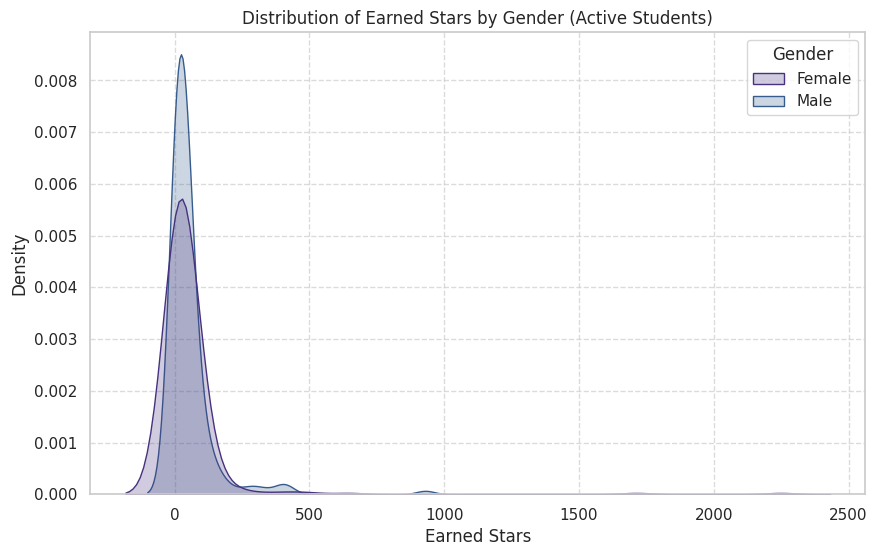

In [91]:
# Create a filtered DataFrame containing only students who have earned more than zero stars
df_active_stars = df[df['Earned Stars'] > 0].copy()

# Create a KDE plot to show the distribution of 'Earned Stars' by 'Gender' for active students
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_active_stars, x='Earned Stars', hue='Gender', fill=True, common_norm=False)
plt.title('Distribution of Earned Stars by Gender (Active Students)')
plt.xlabel('Earned Stars')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

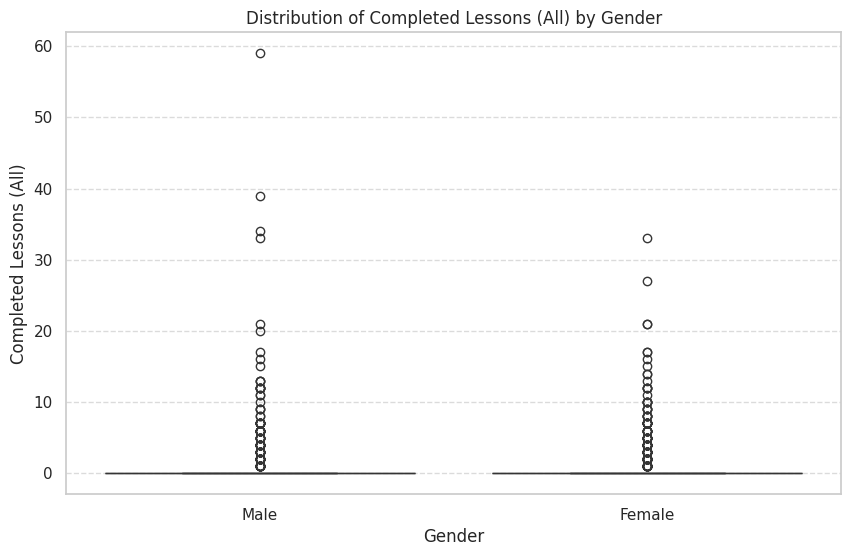

In [79]:
# Create a box plot to compare the distribution of 'Completed Lessons (All)' by 'Gender'
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Gender', y='Completed Lessons (All)', hue='Gender', legend=False)
plt.title('Distribution of Completed Lessons (All) by Gender')
plt.xlabel('Gender')
plt.ylabel('Completed Lessons (All)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

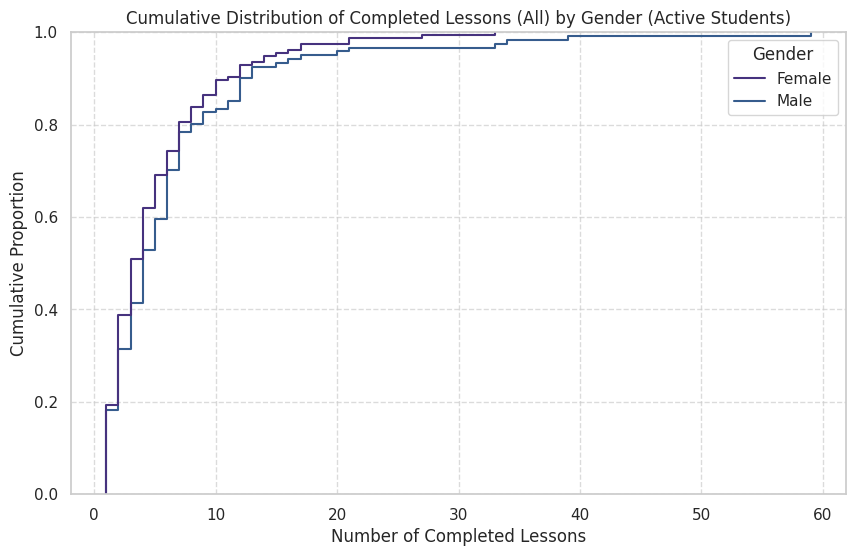

In [92]:
# Create a filtered DataFrame containing only students who have completed at least one lesson
df_active_lessons = df[df['Completed Lessons (All)'] > 0].copy()

# Create a CDF plot to show the cumulative distribution of 'Completed Lessons (All)' by 'Gender' for active students
plt.figure(figsize=(10, 6))
sns.ecdfplot(data=df_active_lessons, x='Completed Lessons (All)', hue='Gender')
plt.title('Cumulative Distribution of Completed Lessons (All) by Gender (Active Students)')
plt.xlabel('Number of Completed Lessons')
plt.ylabel('Cumulative Proportion')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

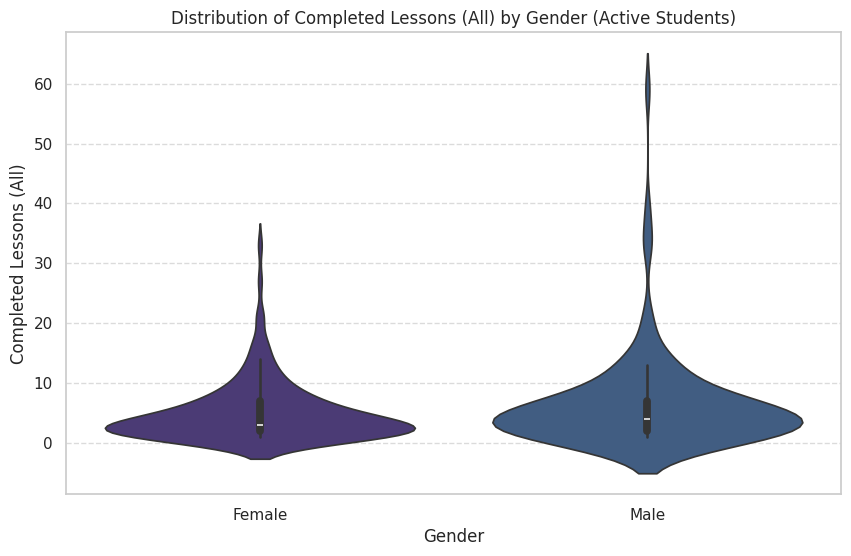

In [86]:
# Create a violin plot to show the distribution of 'Completed Lessons (All)' by 'Gender' for active students
plt.figure(figsize=(10, 6))
sns.violinplot(data=df_active_lessons, x='Gender', y='Completed Lessons (All)', hue='Gender', legend=False)
plt.title('Distribution of Completed Lessons (All) by Gender (Active Students)')
plt.xlabel('Gender')
plt.ylabel('Completed Lessons (All)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

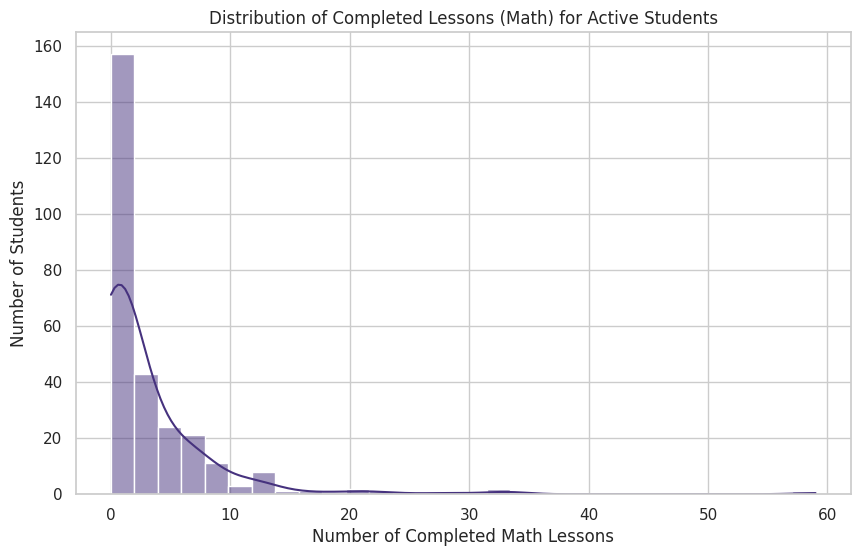

In [81]:
# Create a histogram to visualize the distribution of 'Completed Lessons (Math)' for active students
plt.figure(figsize=(10, 6))
sns.histplot(df_active_lessons['Completed Lessons (Math)'].dropna(), kde=True, bins=30)
plt.title('Distribution of Completed Lessons (Math) for Active Students')
plt.xlabel('Number of Completed Math Lessons')
plt.ylabel('Number of Students')
plt.show()

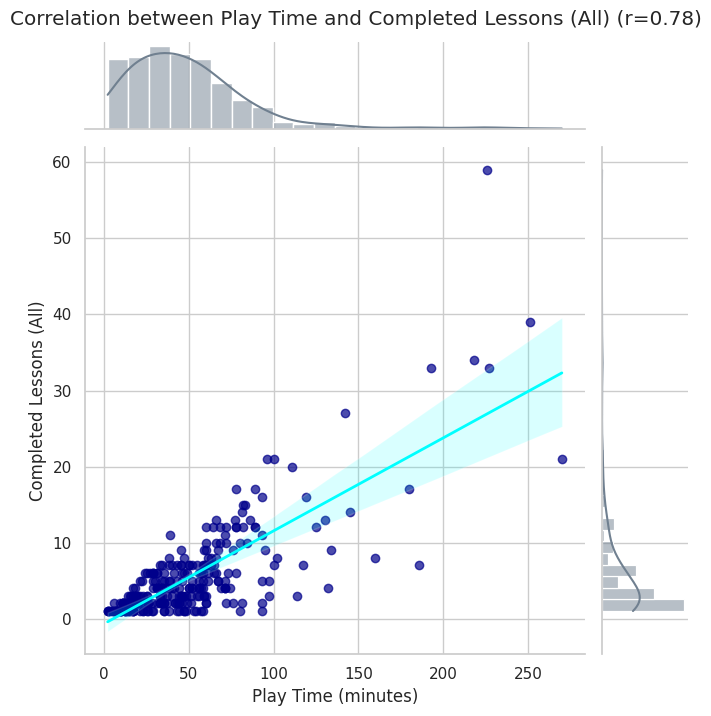

In [90]:
# Analyze the correlation between 'Play Time' and 'Completed Lessons (All)' for active students
# A jointplot provides both the scatter plot and the marginal distributions
import scipy.stats as stats

# Calculate Pearson correlation coefficient
r_value, _ = stats.pearsonr(df_active_lessons['Play Time'], df_active_lessons['Completed Lessons (All)'])

# Create the jointplot with specified colors for scatter, regression line, and marginals
# Setting 'color' directly in jointplot affects the marginals and can be overridden for scatter with scatter_kws
j = sns.jointplot(data=df_active_lessons, x='Play Time', y='Completed Lessons (All)', kind='reg', height=7,
                  color='slategray', # Color for marginal plots
                  scatter_kws={'alpha':0.7, 'color':'darkblue'}, # Dark blue for scatter points
                  line_kws={'color':'cyan', 'lw':2}) # Cyan for regression line

# Add the title and correlation coefficient
j.fig.suptitle(f'Correlation between Play Time and Completed Lessons (All) (r={r_value:.2f})', y=1.02)
j.set_axis_labels('Play Time (minutes)', 'Completed Lessons (All)')
plt.show()

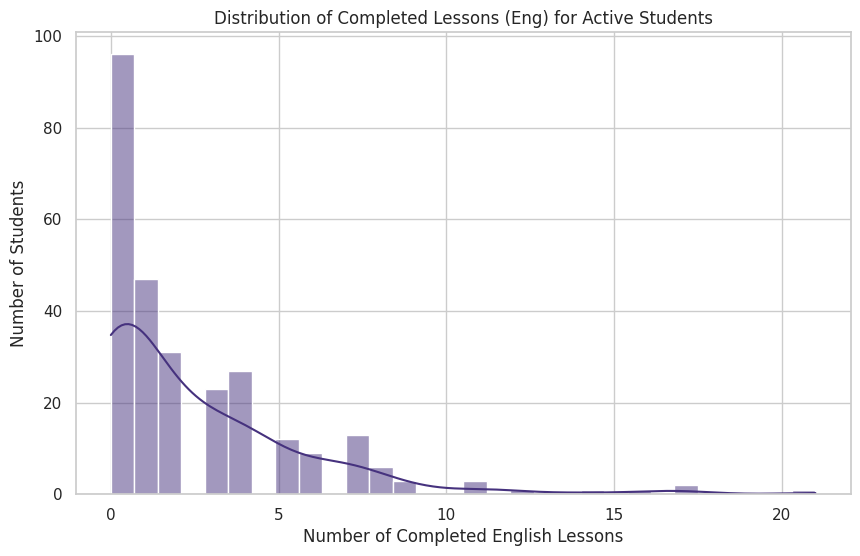

In [82]:
# Create a histogram to visualize the distribution of 'Completed Lessons (Eng)' for active students
plt.figure(figsize=(10, 6))
sns.histplot(df_active_lessons['Completed Lessons (Eng)'].dropna(), kde=True, bins=30)
plt.title('Distribution of Completed Lessons (Eng) for Active Students')
plt.xlabel('Number of Completed English Lessons')
plt.ylabel('Number of Students')
plt.show()

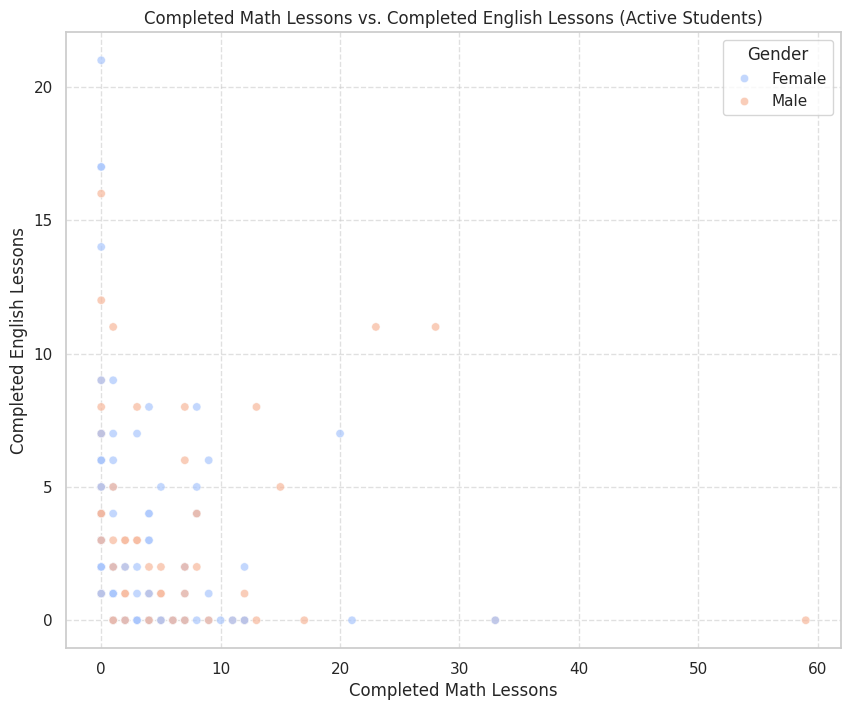

In [83]:
# Create a scatter plot to visualize the relationship between 'Completed Math Lessons' and 'Completed English Lessons' for active students, colored by 'Gender'
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_active_lessons,
                x='Completed Lessons (Math)',
                y='Completed Lessons (Eng)',
                alpha=0.7,
                hue='Gender',  # Add gender as hue for additional insight
                palette='coolwarm') # Use 'coolwarm' palette for gender distinction
plt.title('Completed Math Lessons vs. Completed English Lessons (Active Students)')
plt.xlabel('Completed Math Lessons')
plt.ylabel('Completed English Lessons')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

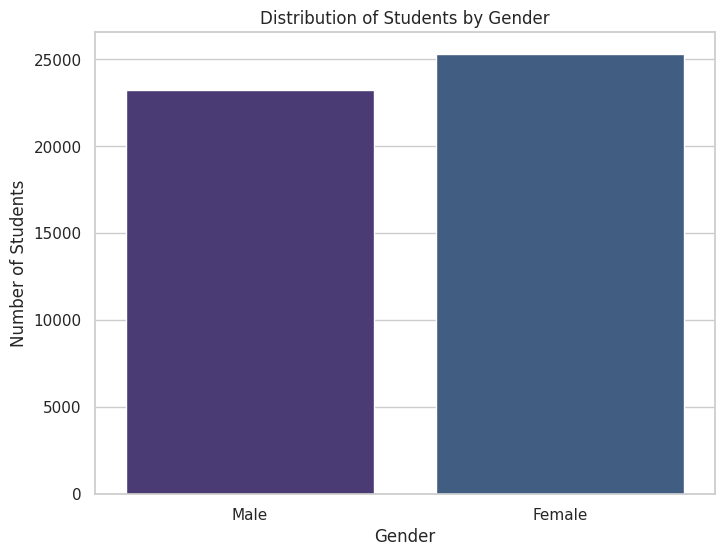

In [84]:
# Create a count plot to visualize the distribution of students by 'Gender'
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Gender', hue='Gender', legend=False)
plt.title('Distribution of Students by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Students')
plt.show()

# 📊 Executive Insights & Recommendations

---

## ⚠️ Important Data Context — Read Before Interpreting

Before drawing conclusions from this dataset, three critical contextual factors must be understood:

1. **This is one app out of seven.** Students in this programme have access to a suite of 7 learning apps. A student showing 0 days played here may be actively engaged on one or more of the other 6 apps. Absence from this app does not indicate overall disengagement.

2. **This is a 3-day reporting window (June 9–11, 2026).** Any student who regularly uses this app but happened not to open it during these 3 days will appear as inactive. This snapshot cannot be used to measure overall or long-term engagement.

3. **The database includes ex-students.** Of 48,569 total records, 28,025 accounts are marked Inactive — representing students who have dropped out, left, or graduated. These students are excluded from engagement analysis where noted.

**All engagement-related insights below are scoped to the 522 students who actively used this app during the reporting window.**

---

## 📋 Reporting Window Summary

| Metric | Value |
|---|---|
| Reporting Period | June 9–11, 2026 (3 days) |
| Total Records in Database | 48,569 |
| Currently Active Accounts | 20,544 |
| Inactive Accounts (ex-students) | 28,025 |
| Students who used this app in window | 522 |
| App in focus | 1 of 7 in the learning suite |

---

## 📌 Insight 1 — Play Time is the Strongest Driver of Learning Outcomes

Among the 522 students who used this app during the reporting window, Play Time and Completed Lessons share a **strong positive correlation of 0.78** — the highest relationship in the dataset. The more time a student spends in the app, the more lessons they complete.

| Play Time Segment | Students |
|---|---|
| 1–10 minutes | 162 (31.0%) |
| 11–30 minutes | 128 (24.5%) |
| 31–60 minutes | 130 (24.9%) |
| 61–120 minutes | 77 (14.8%) |
| 120+ minutes | 15 (2.9%) |

The majority of sessions fall under 30 minutes. Top 10% of learners (those completing 8+ lessons) average **101 minutes** of play time and earn **140 stars on average** — significantly above the overall mean.

**Recommendation:** Encourage teachers to set a session target of at least 30 minutes when assigning this app. Students crossing the 60-minute threshold show markedly better lesson completion. Consider building a simple in-app nudge or teacher dashboard alert when a student crosses key time milestones.

---

## 📌 Insight 2 — Gender Engagement Patterns Differ Meaningfully

| Gender | Students | Avg Lessons | Avg Stars | Avg Play Time |
|---|---|---|---|---|
| Female | 302 (57.9%) | 2.59 | 44.91 | 35.3 mins |
| Male | 220 (42.1%) | 3.52 | 7.19 | 32.6 mins |

Female students earn significantly more stars (44.91 vs 7.19) while male students complete more lessons on average (3.52 vs 2.59). Both genders have similar play times, suggesting they engage differently with the content rather than one group spending more time overall.

**Recommendation:** Investigate whether the star reward system is structured in a way that motivates female students toward star-earning activities over lesson progression. This is not necessarily negative — stars may reflect different types of engagement — but understanding the distinction will help the foundation assess whether lesson completion or star earning is the better proxy for learning outcomes for each gender.

---

## 📌 Insight 3 — Top Performing Schools Offer a Replicable Blueprint

Performance varies significantly across schools. The top schools by average lessons completed during this window:

| School | Students Active | Avg Lessons | Avg Stars | Avg Play Time |
|---|---|---|---|---|
| 288-MS-MPK-MPK | 4 | 12.25 | 104.0 | 90.3 mins |
| 237-MS-KHR-SUK | 4 | 11.50 | 93.3 | 79.8 mins |
| 364-MS-KHI-KRG | 9 | 8.78 | 77.1 | 75.8 mins |
| 357-MS-KHI-MLR | 9 | 7.67 | 68.4 | 52.8 mins |

Top schools by adoption rate among their active accounts:

| School | Adoption Rate |
|---|---|
| 290-MS-MPK-MPK | 47.4% |
| 101-MS-KHI-MLR | 36.4% |
| 362-MS-HYD-HYD | 31.0% |
| 233-MS-KHR-SUK | 30.0% |

Schools in the MPK and MLR regions appear consistently across both performance and adoption rankings.

**Recommendation:** Conduct qualitative interviews with coordinators and teachers at 290-MS-MPK-MPK and 288-MS-MPK-MPK to understand their deployment approach. Are teachers actively assigning the app? Is there a structured session time? Document and share these practices with lower-performing schools as a replicable model.

---

## 📌 Insight 4 — Math Slightly Outperforms English Lesson Completion

Among students who used the app during the window:
- Average Math lessons completed: **1.65**
- Average English lessons completed: **1.33**

Math engagement is modestly stronger than English across the active cohort.

**Recommendation:** This difference alone is not conclusive over a 3-day window. A longer-term dataset would be needed to determine whether English content is genuinely less engaging or whether this is a reporting period artefact. Worth monitoring in future reports.

---

## 📌 Insight 5 — Core Curriculum Dominates Over Library Time

| Time Type | Average (Active Students) |
|---|---|
| Core Time | 29.2 minutes |
| Library Time | 5.1 minutes |
| Ratio | 5.7 : 1 |

Students spend nearly 6x more time on core curriculum than library content.

**Recommendation:** Library content may have low visibility or insufficient teacher promotion. If the foundation's research shows library time correlates with vocabulary or reading retention, consider building structured library time into the recommended session format rather than leaving it as a student-led choice.

---

## 📌 Insight 6 — Data Quality Issues Requiring Engineering Review

Two anomalies were detected that should be flagged to the platform's technical team:

**Negative Earned Stars — 5 students affected:**

| School | Earned Stars |
|---|---|
| 216-MS-BNB-THT | -14 |
| 233-MS-KHR-SUK | -117 |
| 233-MS-KHR-SUK | -114 |
| 289-MS-MPK-MPK | -3,550 |
| 162-MS-HYD-HYD | -4,048 |

Values as extreme as -4,048 stars strongly suggest a scoring engine bug or sync error rather than intentional negative scoring. These records have been excluded from star-related averages in this analysis.

**10 students show as active (Days Played > 0) but have 0 recorded play time** — a data sync inconsistency that should be investigated.

**Recommendation:** Report both issues to the engineering team with the affected Student IDs. The negative star values in particular could be demotivating affected students without anyone being aware.

---

## ✅ Summary of Recommendations

| Priority | Action | Rationale |
|---|---|---|
| 🔴 Critical | Report negative stars bug to engineering with affected Student IDs | Data integrity and student experience |
| 🟠 High | Interview top-performing schools and document replicable practices | Adoption and performance |
| 🟠 High | Set 30-minute session targets when teachers assign this app | Learning outcomes |
| 🟡 Medium | Investigate gender differences in stars vs lesson completion | Equity and content design |
| 🟡 Medium | Promote library content within structured session formats | Retention |
| 🟢 Low | Request cross-app data to understand overall platform engagement | Complete picture |
| 🟢 Low | Monitor Math vs English gap over a longer reporting period | Content effectiveness |

---

## 📎 Limitations of This Analysis

- **3-day window only** — findings reflect a snapshot, not long-term trends. Any metric here should be validated against a full academic term dataset before acting on it.
- **Single app view** — students may be highly engaged across the 7-app suite. Cross-app data is needed for a complete engagement picture.
- **Small active cohort** — 522 students is sufficient for exploratory analysis but some school-level comparisons involve very small groups (3–4 students) and should be interpreted cautiously.
- **No learning outcome validation** — lesson completion and stars are proxy metrics. Their relationship to actual learning outcomes would require assessment data to validate.

---

*Analysis by Hamza Awan — Data Analyst Intern*
*Reporting period: June 9–11, 2026*
*Dataset: 48,569 student records across multiple schools in Pakistan*
